<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/ert_neqsim_integrated_field_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ERT + NeqSim integrated field-development uncertainty

This executable Google Colab notebook runs an ensemble of coupled
**reservoir → well → SURF → process → economics** calculations.
ERT samples and orchestrates the realizations. Every realization runs a
reduced-order, finite-volume waterflood model, nodal well deliverability,
subsea pressure losses, and three exact NeqSim facility snapshots.

The case is synthetic public teaching data. It is intended for early
field-development uncertainty work and workflow development, not as a
history-matched asset model or a design basis.

## Learning outcomes

After running the notebook, you should be able to:

1. configure `GEN_KW`, `GEN_DATA`, a local queue, and a custom forward
   model in ERT;
2. propagate subsurface, well, and SURF uncertainty into facility loads;
3. run NeqSim inside every ERT realization;
4. distinguish technical quantiles from petroleum P10/P50/P90 notation;
5. identify capacity exceedance probabilities and dominant uncertainty
   drivers; and
6. select representative low, median, and high cases for detailed
   engineering.

## Integrated calculation chain

| Stage | Model in each ERT realization | Main outputs |
|---|---|---|
| Reservoir | 40-cell explicit finite-volume waterflood + tank pressure | pressure, saturation, oil/gas/water rates |
| Wells | productivity-index nodal solution | liquid deliverability, BHP, wellhead pressure |
| SURF | tubing, flowline, and riser pressure losses | process arrival pressure |
| Process | NeqSim SRK-CPA, choke, three-phase separator, compressor, cooler | phase loads, power, duty, mass balance |
| Economics | annual discounted cash flow | CAPEX, NPV10 |
| Ensemble | ERT prior sampling and local queue | result span, sensitivities, exceedance probabilities |

The existing deterministic OPM Flow–NeqSim notebook remains the
high-fidelity black-oil reference. This notebook focuses on the ensemble
and decision layer and can later replace its reduced-order reservoir
step with ERT's built-in `FLOW` forward model.

## Physical model

Corey relative permeability is represented by normalized water
saturation $S_w^*$:

$$
S_w^* =
\frac{S_w-S_{wi}}{1-S_{wi}-S_{or}},
$$

$$
k_{rw} = (S_w^*)^{n_w},
\qquad
k_{ro} = (1-S_w^*)^{n_o}.
$$

The water fractional flow is

$$
f_w =
\frac{k_{rw}/\mu_w}
{k_{rw}/\mu_w+k_{ro}/\mu_o}.
$$

The finite-volume saturation update in cell $i$ is

$$
S_{w,i}^{n+1} =
S_{w,i}^{n}
+
\frac{q_{wi}\Delta t}{PV_i}
\left(
f_{w,i-\frac{1}{2}}
-
f_{w,i+\frac{1}{2}}
\right).
$$

Here, $S_{wi}$ and $S_{or}$ are initial water and residual oil
saturation, $n_w$ and $n_o$ are Corey exponents, $\mu$ is viscosity,
$q_{wi}$ is injection rate, and $PV_i$ is cell pore volume.

## Coupled pressure and deliverability

Reservoir pressure is updated with a tank material balance:

$$
\Delta p =
\frac{q_{wi}+q_{aq}-q_{prod}}
{c_t PV}\Delta t.
$$

The field liquid rate is found from the nodal equation

$$
q_L =
J\left[p_R-p_{bh,req}(q_L)\right],
$$

where required bottom-hole pressure includes separator pressure, choke
margin, well hydrostatic head, tubing friction, flowline friction, and
riser hydrostatic head. Pressures are absolute. Rates use standard
cubic metres per day unless explicitly labelled otherwise.

## Uncertainty and quantile convention

ERT samples continuous prior distributions. The ensemble represents
parameter uncertainty conditional on one development concept: four
producers, water injection, one subsea gathering system, and one process
train.

For value metrics such as recoverable oil and NPV:

- **P90** is the conservative 10th percentile;
- **P50** is the median; and
- **P10** is the upside 90th percentile.

For loads such as gas rate, water rate, and compressor power, the
notebook reports **Q10/Q50/Q90** statistical quantiles to avoid reversing
the engineering meaning.

## 1. Clean Colab setup

ERT's published package is pinned for reproducibility. The linked ERT
documentation may describe the next documentation version; the notebook
records the installed runtime version below.

In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
import os
from pathlib import Path
import subprocess
import sys


REQUIRED_PACKAGES = {
    "ert": "23.0.1",
    "neqsim": "3.16.0",
}


def installed_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return None


packages_to_install = [
    f"{package_name}=={required_version}"
    for package_name, required_version in REQUIRED_PACKAGES.items()
    if installed_version(package_name) != required_version
]
if packages_to_install:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *packages_to_install,
        ],
        check=True,
        timeout=900,
    )

python_bin_directory = str(Path(sys.executable).parent)
os.environ["PATH"] = (
    python_bin_directory
    + os.pathsep
    + os.environ.get("PATH", "")
)
os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path.cwd() / ".matplotlib"),
)

Out[1]: '/tmp/mplconfig'


In [2]:
import json
import math
import platform
import shutil
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

runtime_versions = pd.DataFrame(
    {
        "runtime": ["ERT", "NeqSim", "Python"],
        "version": [
            version("ert"),
            version("neqsim"),
            platform.python_version(),
        ],
    }
)
display(runtime_versions)

,runtime,version
0,ERT,23.0.1
1,NeqSim,3.16.0
2,Python,3.12.13


## 2. Prior distributions

The ranges are deliberately broad enough to create a useful teaching
ensemble. They are not calibrated distributions. Correlations between
pore volume, permeability, saturation, and development timing would
normally come from geomodelling and subsurface maturation.

In [3]:
ENSEMBLE_SIZE = 24
RANDOM_SEED = 20260728
MAX_PARALLEL_REALIZATIONS = 2

priors = pd.DataFrame(
    [
        ("OOIP_MSM3", 38.0, 68.0, "MSm³", "oil initially in place"),
        ("PERMEABILITY_MD", 90.0, 420.0, "mD", "effective permeability"),
        ("WELL_PI_MULT", 0.70, 1.30, "-", "well PI multiplier"),
        ("RESIDUAL_OIL_SAT", 0.18, 0.30, "-", "residual oil saturation"),
        ("COREY_WATER_EXP", 1.8, 3.2, "-", "water Corey exponent"),
        ("COREY_OIL_EXP", 1.7, 3.0, "-", "oil Corey exponent"),
        ("AREAL_SWEEP_EFF", 0.55, 0.82, "-", "areal/vertical sweep"),
        ("VOIDAGE_REPLACEMENT", 0.62, 1.02, "-", "injection VRR"),
        ("AQUIFER_STRENGTH", 0.0, 1.4, "-", "aquifer multiplier"),
        ("INITIAL_GOR_SM3_SM3", 130.0, 220.0, "Sm³/Sm³", "initial solution GOR"),
        ("FLOWLINE_LENGTH_KM", 8.0, 32.0, "km", "subsea flowline length"),
        ("WATER_DEPTH_M", 250.0, 450.0, "m", "water depth"),
        ("ROUGHNESS_MULT", 0.8, 1.4, "-", "hydraulic loss multiplier"),
        ("FACILITY_AVAILABILITY", 0.90, 0.98, "-", "uptime fraction"),
    ],
    columns=["parameter", "minimum", "maximum", "unit", "meaning"],
)
display(priors)

,parameter,minimum,maximum,unit,meaning
0,OOIP_MSM3,38.00,68.00,MSm³,oil initially in place
1,PERMEABILITY_MD,90.00,420.00,mD,effective permeability
2,WELL_PI_MULT,0.70,1.30,-,well PI multiplier
3,RESIDUAL_OIL_SAT,0.18,0.30,-,residual oil saturation
4,COREY_WATER_EXP,1.80,3.20,-,water Corey exponent
5,COREY_OIL_EXP,1.70,3.00,-,oil Corey exponent
6,AREAL_SWEEP_EFF,0.55,0.82,-,areal/vertical sweep
7,VOIDAGE_REPLACEMENT,0.62,1.02,-,injection VRR
8,AQUIFER_STRENGTH,0.00,1.40,-,aquifer multiplier
9,INITIAL_GOR_SM3_SM3,130.00,220.00,Sm³/Sm³,initial solution GOR


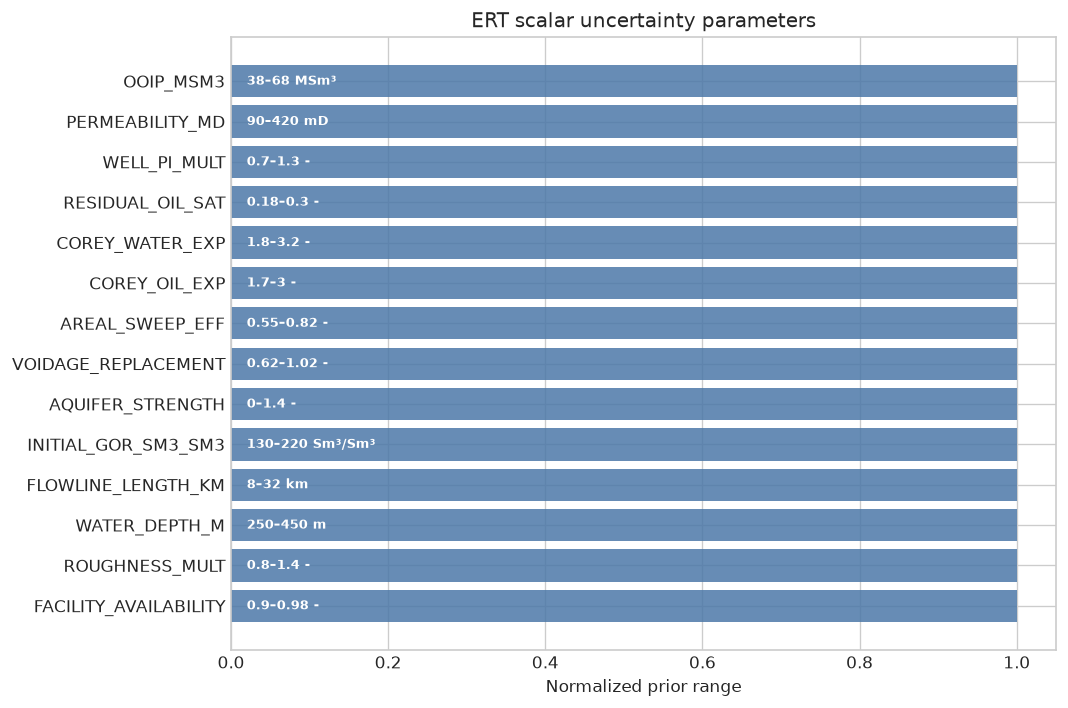

In [4]:
figure, axis = plt.subplots(figsize=(9, 6))
normalized_width = np.ones(len(priors))
axis.barh(
    priors["parameter"],
    normalized_width,
    color="#4C78A8",
    alpha=0.85,
)
axis.set_xlabel("Normalized prior range")
axis.set_title("ERT scalar uncertainty parameters")
axis.set_xlim(0.0, 1.05)
axis.invert_yaxis()
for row_index, row in priors.iterrows():
    label = (
        f"{row['minimum']:g}–{row['maximum']:g} "
        f"{row['unit']}"
    )
    axis.text(
        0.02,
        row_index,
        label,
        va="center",
        color="white",
        fontweight="bold",
        fontsize=8,
    )
figure.tight_layout()
plt.show()

## 3. Generate the ERT project

`GEN_KW` samples the priors and writes `parameters.json` in every
runpath. `GEN_DATA` registers a compact seven-value response vector.
The full time series, NeqSim snapshots, validation report, and economics
remain available in each realization directory.

In [5]:
PROJECT_DIRECTORY = Path("ert_integrated_field_case")
if PROJECT_DIRECTORY.exists():
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    archive_directory = Path(
        f"ert_integrated_field_case_previous_{timestamp}"
    )
    PROJECT_DIRECTORY.rename(archive_directory)
    print(f"Archived previous generated case as {archive_directory}")
PROJECT_DIRECTORY.mkdir(parents=True)

priors_lines = [
    (
        f"{row.parameter} UNIFORM "
        f"{row.minimum:.12g} {row.maximum:.12g}"
    )
    for row in priors.itertuples(index=False)
]
(PROJECT_DIRECTORY / "field_priors.txt").write_text(
    "\n".join(priors_lines) + "\n",
    encoding="utf-8",
)

Archived previous generated case as ert_integrated_field_case_previous_20260729_045428
Out[5]: 449


In [6]:
FORWARD_MODEL_SOURCE = r'''#!/usr/bin/env python
import json
import math
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    cooler,
    runProcess,
    separator3phase,
    stream,
    valve,
)


DAYS_PER_YEAR = 365.25
FORECAST_YEARS = 10.0
REPORT_INTERVAL_DAYS = DAYS_PER_YEAR / 4.0
GRID_CELLS = 40
INITIAL_PRESSURE_BARA = 285.0
BUBBLE_PRESSURE_BARA = 205.0
SEPARATOR_PRESSURE_BARA = 30.0
CHOKE_MARGIN_BAR = 5.0
TVD_M = 2850.0
INITIAL_WATER_SATURATION = 0.22
OIL_FORMATION_VOLUME_FACTOR = 1.25
WATER_VISCOSITY_CP = 0.45
OIL_VISCOSITY_CP = 1.20
TOTAL_COMPRESSIBILITY_PER_BAR = 2.0e-4
OIL_TARGET_SM3_DAY = 15000.0
MAX_LIQUID_RATE_SM3_DAY = 35000.0
MIN_RESERVOIR_PRESSURE_BARA = 75.0


def read_parameters():
    raw_parameters = json.loads(
        Path("parameters.json").read_text(encoding="utf-8")
    )
    return {
        parameter_name: float(parameter_data["value"])
        for parameter_name, parameter_data in raw_parameters.items()
    }


def fractional_flow(
    water_saturation,
    residual_oil_saturation,
    water_exponent,
    oil_exponent,
):
    movable_range = (
        1.0 - INITIAL_WATER_SATURATION - residual_oil_saturation
    )
    normalized_water = np.clip(
        (water_saturation - INITIAL_WATER_SATURATION) / movable_range,
        0.0,
        1.0,
    )
    relative_water = normalized_water**water_exponent
    relative_oil = (1.0 - normalized_water) ** oil_exponent
    water_mobility = relative_water / WATER_VISCOSITY_CP
    oil_mobility = relative_oil / OIL_VISCOSITY_CP
    return water_mobility / np.maximum(
        water_mobility + oil_mobility,
        1.0e-12,
    )


def pressure_losses(
    liquid_rate_sm3_day,
    water_fraction,
    solution_gor_sm3_sm3,
    parameters,
):
    rate_per_well = liquid_rate_sm3_day / 4.0
    mixture_density_kg_m3 = np.clip(
        535.0
        + 270.0 * water_fraction
        - 0.40 * (solution_gor_sm3_sm3 - 150.0),
        300.0,
        830.0,
    )
    well_hydrostatic_bar = (
        mixture_density_kg_m3 * 9.81 * TVD_M / 1.0e5
    )
    tubing_friction_bar = (
        1.8
        * parameters["ROUGHNESS_MULT"]
        * (max(rate_per_well, 0.0) / 3000.0) ** 1.75
    )
    flowline_friction_bar = (
        parameters["ROUGHNESS_MULT"]
        * parameters["FLOWLINE_LENGTH_KM"]
        * (
            0.010 * (max(liquid_rate_sm3_day, 0.0) / 1000.0) ** 1.65
            + 0.0010
            * (
                max(
                    liquid_rate_sm3_day * solution_gor_sm3_sm3,
                    0.0,
                )
                / 1.0e5
            )
            ** 1.35
        )
    )
    riser_hydrostatic_bar = (
        mixture_density_kg_m3
        * 9.81
        * parameters["WATER_DEPTH_M"]
        / 1.0e5
    )
    return {
        "mixture_density_kg_m3": mixture_density_kg_m3,
        "well_hydrostatic_bar": well_hydrostatic_bar,
        "tubing_friction_bar": tubing_friction_bar,
        "flowline_friction_bar": flowline_friction_bar,
        "riser_hydrostatic_bar": riser_hydrostatic_bar,
    }


def required_bottomhole_pressure(
    liquid_rate_sm3_day,
    water_fraction,
    solution_gor_sm3_sm3,
    parameters,
):
    losses = pressure_losses(
        liquid_rate_sm3_day,
        water_fraction,
        solution_gor_sm3_sm3,
        parameters,
    )
    bottomhole_pressure_bara = (
        SEPARATOR_PRESSURE_BARA
        + CHOKE_MARGIN_BAR
        + losses["well_hydrostatic_bar"]
        + losses["tubing_friction_bar"]
        + losses["flowline_friction_bar"]
        + losses["riser_hydrostatic_bar"]
    )
    return bottomhole_pressure_bara, losses


def solve_liquid_rate(
    reservoir_pressure_bara,
    water_fraction,
    solution_gor_sm3_sm3,
    parameters,
):
    permeability_scale = parameters["PERMEABILITY_MD"] / 220.0
    field_productivity = (
        210.0
        * permeability_scale**0.72
        * parameters["WELL_PI_MULT"]
    )

    def residual(liquid_rate):
        required_bhp, _ = required_bottomhole_pressure(
            liquid_rate,
            water_fraction,
            solution_gor_sm3_sm3,
            parameters,
        )
        deliverable_rate = field_productivity * max(
            reservoir_pressure_bara - required_bhp,
            0.0,
        )
        return liquid_rate - deliverable_rate

    if residual(0.0) >= 0.0:
        return 0.0

    lower_rate = 0.0
    upper_rate = MAX_LIQUID_RATE_SM3_DAY
    for _ in range(60):
        midpoint_rate = 0.5 * (lower_rate + upper_rate)
        if residual(midpoint_rate) > 0.0:
            upper_rate = midpoint_rate
        else:
            lower_rate = midpoint_rate
    return 0.5 * (lower_rate + upper_rate)


def calculate_rates(
    reservoir_pressure_bara,
    producer_water_saturation,
    remaining_recoverable_oil_sm3,
    parameters,
):
    water_fraction = float(
        fractional_flow(
            np.array([producer_water_saturation]),
            parameters["RESIDUAL_OIL_SAT"],
            parameters["COREY_WATER_EXP"],
            parameters["COREY_OIL_EXP"],
        )[0]
    )
    pressure_deficit = max(
        BUBBLE_PRESSURE_BARA - reservoir_pressure_bara,
        0.0,
    )
    solution_gor = parameters["INITIAL_GOR_SM3_SM3"] * (
        1.0 + 1.8 * pressure_deficit / BUBBLE_PRESSURE_BARA
    )
    liquid_potential = solve_liquid_rate(
        reservoir_pressure_bara,
        water_fraction,
        solution_gor,
        parameters,
    )
    oil_potential = (
        liquid_potential
        * (1.0 - water_fraction)
        / OIL_FORMATION_VOLUME_FACTOR
    )
    oil_rate = min(
        oil_potential,
        OIL_TARGET_SM3_DAY,
        max(
            remaining_recoverable_oil_sm3 / REPORT_INTERVAL_DAYS,
            0.0,
        ),
    )
    if oil_potential > 1.0e-12:
        liquid_rate = liquid_potential * oil_rate / oil_potential
    else:
        liquid_rate = 0.0
    water_rate = liquid_rate * water_fraction
    gas_rate = oil_rate * solution_gor
    bottomhole_pressure, losses = required_bottomhole_pressure(
        liquid_rate,
        water_fraction,
        solution_gor,
        parameters,
    )
    wellhead_pressure = (
        bottomhole_pressure
        - losses["well_hydrostatic_bar"]
        - losses["tubing_friction_bar"]
    )
    arrival_pressure = (
        wellhead_pressure
        - losses["flowline_friction_bar"]
        - losses["riser_hydrostatic_bar"]
    )
    return {
        "oil_rate_sm3_day": oil_rate,
        "gas_rate_sm3_day": gas_rate,
        "water_rate_sm3_day": water_rate,
        "liquid_rate_sm3_day": liquid_rate,
        "water_cut_fraction": water_fraction,
        "gor_sm3_sm3": solution_gor,
        "bottomhole_pressure_bara": bottomhole_pressure,
        "wellhead_pressure_bara": wellhead_pressure,
        "arrival_pressure_bara": arrival_pressure,
    }


def advance_saturation(
    water_saturation,
    injection_rate_sm3_day,
    pore_volume_sm3,
    duration_days,
    parameters,
):
    cell_pore_volume = pore_volume_sm3 / GRID_CELLS
    maximum_substep = max(
        min(
            10.0,
            0.15
            * cell_pore_volume
            / max(injection_rate_sm3_day, 1.0),
        ),
        0.25,
    )
    number_of_substeps = max(
        1,
        int(math.ceil(duration_days / maximum_substep)),
    )
    substep_days = duration_days / number_of_substeps
    updated_saturation = water_saturation.copy()

    for _ in range(number_of_substeps):
        cell_fractional_flow = fractional_flow(
            updated_saturation,
            parameters["RESIDUAL_OIL_SAT"],
            parameters["COREY_WATER_EXP"],
            parameters["COREY_OIL_EXP"],
        )
        water_flux_fraction = np.concatenate(
            ([1.0], cell_fractional_flow)
        )
        saturation_change = (
            injection_rate_sm3_day
            * substep_days
            / cell_pore_volume
            * (
                water_flux_fraction[:-1]
                - water_flux_fraction[1:]
            )
        )
        updated_saturation = np.clip(
            updated_saturation + saturation_change,
            INITIAL_WATER_SATURATION,
            1.0 - parameters["RESIDUAL_OIL_SAT"],
        )
    return updated_saturation


def simulate_reservoir_well_and_surf(parameters):
    ooip_sm3 = parameters["OOIP_MSM3"] * 1.0e6
    pore_volume_sm3 = (
        ooip_sm3
        * OIL_FORMATION_VOLUME_FACTOR
        / (1.0 - INITIAL_WATER_SATURATION)
    )
    displacement_efficiency = 1.0 - (
        parameters["RESIDUAL_OIL_SAT"]
        / (1.0 - INITIAL_WATER_SATURATION)
    )
    recoverable_oil_sm3 = (
        ooip_sm3
        * displacement_efficiency
        * parameters["AREAL_SWEEP_EFF"]
    )
    water_saturation = np.full(
        GRID_CELLS,
        INITIAL_WATER_SATURATION,
    )
    reservoir_pressure = INITIAL_PRESSURE_BARA
    cumulative_oil = 0.0
    cumulative_gas = 0.0
    cumulative_water = 0.0
    cumulative_injection = 0.0
    history_rows = []
    report_days = np.arange(
        0.0,
        FORECAST_YEARS * DAYS_PER_YEAR + 0.5,
        REPORT_INTERVAL_DAYS,
    )

    for report_index, report_day in enumerate(report_days):
        remaining_recoverable = max(
            recoverable_oil_sm3 - cumulative_oil,
            0.0,
        )
        rates = calculate_rates(
            reservoir_pressure,
            water_saturation[-1],
            remaining_recoverable,
            parameters,
        )
        history_rows.append(
            {
                "year": report_day / DAYS_PER_YEAR,
                "reservoir_pressure_bara": reservoir_pressure,
                "producer_water_saturation": water_saturation[-1],
                "average_water_saturation": water_saturation.mean(),
                "cumulative_oil_msm3": cumulative_oil / 1.0e6,
                "cumulative_gas_bsm3": cumulative_gas / 1.0e9,
                "cumulative_water_msm3": cumulative_water / 1.0e6,
                "cumulative_injection_msm3": (
                    cumulative_injection / 1.0e6
                ),
                **rates,
            }
        )
        if report_index == len(report_days) - 1:
            break

        duration_days = report_days[report_index + 1] - report_day
        uptime = parameters["FACILITY_AVAILABILITY"]
        average_liquid_rate = rates["liquid_rate_sm3_day"] * uptime
        produced_reservoir_volume = (
            rates["oil_rate_sm3_day"] * OIL_FORMATION_VOLUME_FACTOR
            + rates["water_rate_sm3_day"]
        ) * uptime
        injection_capacity = (
            12000.0
            * (parameters["PERMEABILITY_MD"] / 220.0) ** 0.60
        )
        target_injection_rate = (
            parameters["VOIDAGE_REPLACEMENT"]
            * produced_reservoir_volume
        )
        injection_rate = min(
            max(target_injection_rate, 0.0),
            injection_capacity,
        )
        aquifer_rate = (
            110.0
            * parameters["AQUIFER_STRENGTH"]
            * max(INITIAL_PRESSURE_BARA - reservoir_pressure, 0.0)
        )
        pressure_change = (
            (
                injection_rate
                + aquifer_rate
                - produced_reservoir_volume
            )
            * duration_days
            / (
                TOTAL_COMPRESSIBILITY_PER_BAR
                * pore_volume_sm3
            )
        )
        reservoir_pressure = np.clip(
            reservoir_pressure + pressure_change,
            MIN_RESERVOIR_PRESSURE_BARA,
            INITIAL_PRESSURE_BARA + 5.0,
        )
        water_saturation = advance_saturation(
            water_saturation,
            injection_rate,
            pore_volume_sm3,
            duration_days,
            parameters,
        )
        cumulative_oil += (
            rates["oil_rate_sm3_day"] * uptime * duration_days
        )
        cumulative_gas += (
            rates["gas_rate_sm3_day"] * uptime * duration_days
        )
        cumulative_water += (
            rates["water_rate_sm3_day"] * uptime * duration_days
        )
        cumulative_injection += injection_rate * duration_days

    history = pd.DataFrame(history_rows)
    history["operating_fraction"] = parameters["FACILITY_AVAILABILITY"]
    return history, water_saturation, {
        "ooip_msm3": ooip_sm3 / 1.0e6,
        "recoverable_oil_msm3": recoverable_oil_sm3 / 1.0e6,
        "pore_volume_msm3": pore_volume_sm3 / 1.0e6,
        "final_cumulative_oil_msm3": cumulative_oil / 1.0e6,
        "final_cumulative_gas_bsm3": cumulative_gas / 1.0e9,
        "final_cumulative_water_msm3": cumulative_water / 1.0e6,
    }


def build_neqsim_feed(row):
    standard_molar_volume_sm3_kmol = 23.69
    gas_kmol_s = (
        row["gas_rate_sm3_day"]
        / standard_molar_volume_sm3_kmol
        / 86400.0
    )
    oil_molar_mass_kg_kmol = 151.0
    oil_kmol_s = (
        row["oil_rate_sm3_day"]
        * 820.0
        / oil_molar_mass_kg_kmol
        / 86400.0
    )
    water_kmol_s = (
        row["water_rate_sm3_day"]
        * 1000.0
        / 18.015
        / 86400.0
    )
    feed = jneqsim.thermo.system.SystemSrkCPAstatoil(
        298.15,
        max(float(row["arrival_pressure_bara"]), 31.0),
    )
    gas_composition = {
        "methane": 0.85,
        "ethane": 0.08,
        "propane": 0.04,
        "n-butane": 0.03,
    }
    for component_name, mole_fraction in gas_composition.items():
        feed.addComponent(
            component_name,
            gas_kmol_s * mole_fraction,
        )
    feed.addComponent("n-heptane", oil_kmol_s * 0.45)
    feed.addTBPfraction(
        "C10",
        oil_kmol_s * 0.35,
        0.142,
        0.78,
    )
    feed.addTBPfraction(
        "C16",
        oil_kmol_s * 0.20,
        0.225,
        0.84,
    )
    feed.addComponent("water", water_kmol_s)
    feed.setMixingRule(10)
    feed.setMultiPhaseCheck(True)
    feed.init(0)
    total_mass_kg_s = (
        row["oil_rate_sm3_day"] * 820.0
        + row["water_rate_sm3_day"] * 1000.0
        + row["gas_rate_sm3_day"] * 0.85
    ) / 86400.0
    return feed, total_mass_kg_s


def run_neqsim_process(row, snapshot_name):
    clearProcess()
    feed_fluid, feed_mass_kg_s = build_neqsim_feed(row)
    inlet = stream(f"{snapshot_name} inlet", feed_fluid)
    inlet.setFlowRate(feed_mass_kg_s, "kg/sec")
    inlet.setTemperature(25.0, "C")
    inlet.setPressure(
        max(float(row["arrival_pressure_bara"]), 31.0),
        "bara",
    )
    inlet_choke = valve(f"{snapshot_name} choke", inlet)
    inlet_choke.setOutletPressure(SEPARATOR_PRESSURE_BARA, "bara")
    hp_separator = separator3phase(
        f"{snapshot_name} HP separator",
        inlet_choke.getOutletStream(),
    )
    gas_compressor = compressor(
        f"{snapshot_name} export compressor",
        hp_separator.getGasOutStream(),
    )
    gas_compressor.setOutletPressure(110.0, "bara")
    gas_compressor.setIsentropicEfficiency(0.78)
    aftercooler = cooler(
        f"{snapshot_name} aftercooler",
        gas_compressor.getOutletStream(),
    )
    aftercooler.setOutTemperature(35.0, "C")
    runProcess()
    outlet_mass_kg_s = (
        hp_separator.getGasOutStream().getFlowRate("kg/sec")
        + hp_separator.getOilOutStream().getFlowRate("kg/sec")
        + hp_separator.getWaterOutStream().getFlowRate("kg/sec")
    )
    return {
        "snapshot": snapshot_name,
        "year": float(row["year"]),
        "feed_mass_kg_s": float(inlet.getFlowRate("kg/sec")),
        "gas_mass_kg_s": float(
            hp_separator.getGasOutStream().getFlowRate("kg/sec")
        ),
        "oil_mass_kg_s": float(
            hp_separator.getOilOutStream().getFlowRate("kg/sec")
        ),
        "water_mass_kg_s": float(
            hp_separator.getWaterOutStream().getFlowRate("kg/sec")
        ),
        "compressor_power_mw": float(gas_compressor.getPower() / 1.0e6),
        "aftercooler_duty_mw": float(aftercooler.getDuty() / 1.0e6),
        "mass_residual_kg_s": float(
            inlet.getFlowRate("kg/sec") - outlet_mass_kg_s
        ),
        "export_pressure_bara": float(
            aftercooler.getOutletStream().getPressure("bara")
        ),
    }


def evaluate_process_snapshots(history):
    snapshot_indices = {
        "peak_oil": int(history["oil_rate_sm3_day"].idxmax()),
        "peak_gas": int(history["gas_rate_sm3_day"].idxmax()),
        "peak_water": int(history["water_rate_sm3_day"].idxmax()),
    }
    results = []
    for snapshot_name, snapshot_index in snapshot_indices.items():
        results.append(
            run_neqsim_process(
                history.loc[snapshot_index],
                snapshot_name,
            )
        )
    return pd.DataFrame(results)


def calculate_economics(history, process_results, parameters):
    oil_value_nok_sm3 = 3200.0
    gas_value_nok_sm3 = 1.15
    annual_opex_bn_nok = 1.20
    carbon_price_nok_tonne = 2000.0
    power_emissions_tonne_mwh = 0.42
    capex_bn_nok = (
        17.0
        + 0.055 * parameters["FLOWLINE_LENGTH_KM"]
        + 0.9 * parameters["WATER_DEPTH_M"] / 300.0
    )
    peak_power_mw = process_results["compressor_power_mw"].max()
    yearly_cashflows_bn_nok = [-capex_bn_nok]
    for year_index in range(int(FORECAST_YEARS)):
        year_slice = history.loc[
            (history["year"] >= year_index)
            & (history["year"] <= year_index + 1)
        ]
        if len(year_slice) < 2:
            continue
        year_values = year_slice["year"].to_numpy()
        oil_volume_sm3 = np.trapezoid(
            year_slice["oil_rate_sm3_day"],
            year_values,
        ) * DAYS_PER_YEAR
        gas_volume_sm3 = np.trapezoid(
            year_slice["gas_rate_sm3_day"],
            year_values,
        ) * DAYS_PER_YEAR
        gas_scale = (
            year_slice["gas_rate_sm3_day"].mean()
            / max(history["gas_rate_sm3_day"].max(), 1.0)
        )
        annual_emissions_tonne = (
            peak_power_mw
            * gas_scale
            * 24.0
            * DAYS_PER_YEAR
            * power_emissions_tonne_mwh
        )
        revenue_bn_nok = (
            oil_volume_sm3 * oil_value_nok_sm3
            + gas_volume_sm3 * gas_value_nok_sm3
        ) / 1.0e9
        carbon_cost_bn_nok = (
            annual_emissions_tonne
            * carbon_price_nok_tonne
            / 1.0e9
        )
        yearly_cashflows_bn_nok.append(
            revenue_bn_nok
            - annual_opex_bn_nok
            - carbon_cost_bn_nok
        )
    discount_factors = [
        (1.0 + 0.10) ** year
        for year in range(len(yearly_cashflows_bn_nok))
    ]
    npv_bn_nok = sum(
        cashflow / discount_factor
        for cashflow, discount_factor in zip(
            yearly_cashflows_bn_nok,
            discount_factors,
        )
    )
    return npv_bn_nok, yearly_cashflows_bn_nok, capex_bn_nok


def first_crossing_year(series, threshold):
    crossing = np.flatnonzero(series.to_numpy() >= threshold)
    if len(crossing) == 0:
        return float("nan")
    return float(crossing[0] / 4.0)


def main():
    parameters = read_parameters()
    history, final_saturation, reservoir_metrics = (
        simulate_reservoir_well_and_surf(parameters)
    )
    process_results = evaluate_process_snapshots(history)
    npv_bn_nok, yearly_cashflows, capex_bn_nok = calculate_economics(
        history,
        process_results,
        parameters,
    )
    maximum_mass_residual = float(
        process_results["mass_residual_kg_s"].abs().max()
    )
    metrics = {
        **parameters,
        **reservoir_metrics,
        "npv10_bn_nok": float(npv_bn_nok),
        "capex_bn_nok": float(capex_bn_nok),
        "peak_oil_rate_sm3_day": float(
            history["oil_rate_sm3_day"].max()
        ),
        "peak_gas_rate_msm3_day": float(
            history["gas_rate_sm3_day"].max() / 1.0e6
        ),
        "peak_water_rate_sm3_day": float(
            history["water_rate_sm3_day"].max()
        ),
        "peak_compressor_power_mw": float(
            process_results["compressor_power_mw"].max()
        ),
        "peak_cooling_duty_mw": float(
            -process_results["aftercooler_duty_mw"].min()
        ),
        "final_pressure_bara": float(
            history["reservoir_pressure_bara"].iloc[-1]
        ),
        "minimum_arrival_pressure_bara": float(
            history.loc[
                history["liquid_rate_sm3_day"] > 1.0,
                "arrival_pressure_bara",
            ].min()
        ),
        "water_breakthrough_year": first_crossing_year(
            history["water_cut_fraction"],
            0.05,
        ),
        "maximum_process_mass_residual_kg_s": maximum_mass_residual,
        "yearly_cashflows_bn_nok": yearly_cashflows,
    }
    validation_checks = {
        "finite time-series values": bool(
            np.isfinite(
                history.select_dtypes(include=[np.number]).to_numpy()
            ).all()
        ),
        "non-negative production rates": bool(
            (
                history[
                    [
                        "oil_rate_sm3_day",
                        "gas_rate_sm3_day",
                        "water_rate_sm3_day",
                    ]
                ].to_numpy()
                >= -1.0e-9
            ).all()
        ),
        "physical saturation range": bool(
            final_saturation.min()
            >= INITIAL_WATER_SATURATION - 1.0e-10
            and final_saturation.max()
            <= 1.0 - parameters["RESIDUAL_OIL_SAT"] + 1.0e-10
        ),
        "oil recovery below recoverable oil": bool(
            metrics["final_cumulative_oil_msm3"]
            <= metrics["recoverable_oil_msm3"] + 1.0e-6
        ),
        "reservoir pressure bounded": bool(
            history["reservoir_pressure_bara"].min()
            >= MIN_RESERVOIR_PRESSURE_BARA - 1.0e-9
            and history["reservoir_pressure_bara"].max()
            <= INITIAL_PRESSURE_BARA + 5.0 + 1.0e-9
        ),
        "arrival pressure supports separator": bool(
            history.loc[
                history["liquid_rate_sm3_day"] > 1.0,
                "arrival_pressure_bara",
            ].min()
            >= SEPARATOR_PRESSURE_BARA + CHOKE_MARGIN_BAR - 0.05
        ),
        "NeqSim compressor raises pressure": bool(
            (
                process_results["export_pressure_bara"]
                > SEPARATOR_PRESSURE_BARA
            ).all()
        ),
        "NeqSim compressor power positive": bool(
            (process_results["compressor_power_mw"] > 0.0).all()
        ),
        "NeqSim cooler removes heat": bool(
            (process_results["aftercooler_duty_mw"] < 0.0).all()
        ),
        "NeqSim process mass closes": bool(
            maximum_mass_residual < 1.0e-7
        ),
    }
    failed_checks = [
        check_name
        for check_name, passed in validation_checks.items()
        if not passed
    ]
    if failed_checks:
        raise AssertionError(
            f"Integrated realization failed checks: {failed_checks}"
        )

    history.to_csv("timeseries.csv", index=False)
    process_results.to_csv("process_snapshots.csv", index=False)
    np.save("final_water_saturation.npy", final_saturation)
    Path("metrics.json").write_text(
        json.dumps(metrics, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    Path("validation.json").write_text(
        json.dumps(validation_checks, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )
    response_values = [
        metrics["final_cumulative_oil_msm3"],
        metrics["peak_gas_rate_msm3_day"],
        metrics["peak_water_rate_sm3_day"],
        metrics["peak_compressor_power_mw"],
        metrics["final_pressure_bara"],
        metrics["minimum_arrival_pressure_bara"],
        metrics["npv10_bn_nok"],
    ]
    Path("integrated_response.out").write_text(
        "\n".join(f"{value:.12g}" for value in response_values) + "\n",
        encoding="utf-8",
    )
    success_payload = {
        "checks_passed": len(validation_checks),
        "checks_total": len(validation_checks),
        "status": "success",
    }
    Path("SUCCESS.json").write_text(
        json.dumps(success_payload, indent=2, sort_keys=True) + "\n",
        encoding="utf-8",
    )


if __name__ == "__main__":
    main()
'''

forward_model_path = (
    PROJECT_DIRECTORY / "integrated_forward_model.py"
)
forward_model_path.write_text(
    FORWARD_MODEL_SOURCE,
    encoding="utf-8",
)
forward_model_path.chmod(0o755)
print(
    f"Forward model: {len(FORWARD_MODEL_SOURCE.splitlines())} "
    "readable Python lines"
)

Forward model: 813 readable Python lines


In [7]:
job_configuration = """        EXECUTABLE integrated_forward_model.py
TARGET_FILE SUCCESS.json
"""
(PROJECT_DIRECTORY / "INTEGRATED_FIELD_JOB").write_text(
    job_configuration,
    encoding="utf-8",
)

ert_configuration = f"""        NUM_REALIZATIONS {ENSEMBLE_SIZE}
MIN_REALIZATIONS {ENSEMBLE_SIZE}
RANDOM_SEED {RANDOM_SEED}

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING {MAX_PARALLEL_REALIZATIONS}

RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW FIELD field_priors.txt
GEN_DATA INTEGRATED_RESPONSE RESULT_FILE:integrated_response.out

INSTALL_JOB INTEGRATED_FIELD INTEGRATED_FIELD_JOB
FORWARD_MODEL INTEGRATED_FIELD
"""
ert_config_path = PROJECT_DIRECTORY / "integrated_field.ert"
ert_config_path.write_text(
    ert_configuration,
    encoding="utf-8",
)
print(ert_configuration)

        NUM_REALIZATIONS 24
MIN_REALIZATIONS 24
RANDOM_SEED 20260728

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2

RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW FIELD field_priors.txt
GEN_DATA INTEGRATED_RESPONSE RESULT_FILE:integrated_response.out

INSTALL_JOB INTEGRATED_FIELD INTEGRATED_FIELD_JOB
FORWARD_MODEL INTEGRATED_FIELD



ERT's `MAX_RUNNING` is kept at two because every worker starts a Java
virtual machine for NeqSim. Increasing it can reduce runtime on a larger
machine but may exceed Colab memory.

In [8]:
lint_run = subprocess.run(
    ["ert", "lint", "integrated_field.ert"],
    cwd=PROJECT_DIRECTORY,
    capture_output=True,
    text=True,
    timeout=120,
)
print(lint_run.stdout.strip())
if lint_run.stderr.strip():
    print(lint_run.stderr.strip())
if lint_run.returncode != 0:
    raise RuntimeError("ERT configuration lint failed.")

Found no errors


## 4. Run the ERT ensemble

Each realization performs all model stages, writes a success target, and
must pass ten engineering assertions. The run uses ERT's headless
`ensemble_experiment` command, which is suitable for Colab and CI.

In [9]:
ensemble_start = time.perf_counter()
ensemble_run = subprocess.run(
    [
        "ert",
        "ensemble_experiment",
        "integrated_field.ert",
        "--disable-monitoring",
        "--experiment-name",
        "integrated-field-development",
        "--current-ensemble",
        "prior",
    ],
    cwd=PROJECT_DIRECTORY,
    capture_output=True,
    text=True,
    timeout=1200,
)
ensemble_elapsed_seconds = time.perf_counter() - ensemble_start
ensemble_log = (
    ensemble_run.stdout.splitlines()
    + ensemble_run.stderr.splitlines()
)
print(
    f"ERT return code: {ensemble_run.returncode}; "
    f"elapsed: {ensemble_elapsed_seconds:.1f} s"
)
for log_line in ensemble_log[-20:]:
    print(log_line)

ERT return code: 0; elapsed: 38.6 s
Please be aware of the following:
- Previously generated results might be overwritten.
- Previously generated files might be used if not configured correctly.
- 24 out of 24 realizations are running in existing runpaths.



In [10]:
run_directories = sorted(
    (PROJECT_DIRECTORY / "runs").glob(
        "realization-*/iter-0"
    ),
    key=lambda path: int(path.parent.name.split("-")[-1]),
)
successful_run_directories = [
    run_directory
    for run_directory in run_directories
    if (run_directory / "SUCCESS.json").exists()
]
failed_run_directories = [
    run_directory
    for run_directory in run_directories
    if not (run_directory / "SUCCESS.json").exists()
]
execution_audit = pd.DataFrame(
    {
        "quantity": [
            "configured realizations",
            "created runpaths",
            "successful realizations",
            "failed realizations",
            "elapsed time",
        ],
        "value": [
            ENSEMBLE_SIZE,
            len(run_directories),
            len(successful_run_directories),
            len(failed_run_directories),
            ensemble_elapsed_seconds,
        ],
        "unit": [
            "count",
            "count",
            "count",
            "count",
            "s",
        ],
    }
)
display(execution_audit)
if len(successful_run_directories) != ENSEMBLE_SIZE:
    raise RuntimeError(
        "Not all ERT realizations completed successfully: "
        f"{failed_run_directories}"
    )

,quantity,value,unit
0,configured realizations,24.000000,count
1,created runpaths,24.000000,count
2,successful realizations,24.000000,count
3,failed realizations,0.000000,count
4,elapsed time,38.576891,s


## 5. Collect realization outputs

ERT owns sampling, runpath creation, scheduling, and response
registration. The analysis below reads the auditable CSV and JSON
products written by each coupled forward model.

In [11]:
metric_rows = []
time_series_by_realization = {}
process_rows = []
saturation_by_realization = {}
validation_rows = []

for run_directory in successful_run_directories:
    realization = int(run_directory.parent.name.split("-")[-1])
    metric_data = json.loads(
        (run_directory / "metrics.json").read_text(
            encoding="utf-8"
        )
    )
    metric_data["realization"] = realization
    metric_rows.append(metric_data)

    time_series = pd.read_csv(
        run_directory / "timeseries.csv"
    )
    time_series["realization"] = realization
    time_series_by_realization[realization] = time_series

    process_table = pd.read_csv(
        run_directory / "process_snapshots.csv"
    )
    process_table["realization"] = realization
    process_rows.append(process_table)

    saturation_by_realization[realization] = np.load(
        run_directory / "final_water_saturation.npy"
    )
    validation_data = json.loads(
        (run_directory / "validation.json").read_text(
            encoding="utf-8"
        )
    )
    for check_name, passed in validation_data.items():
        validation_rows.append(
            {
                "realization": realization,
                "check": check_name,
                "passed": bool(passed),
            }
        )

metrics = pd.DataFrame(metric_rows).sort_values(
    "realization"
)
process_snapshots = pd.concat(
    process_rows,
    ignore_index=True,
)
validation_results = pd.DataFrame(validation_rows)
display(
    metrics[
        [
            "realization",
            "final_cumulative_oil_msm3",
            "peak_gas_rate_msm3_day",
            "peak_water_rate_sm3_day",
            "peak_compressor_power_mw",
            "npv10_bn_nok",
        ]
    ].head()
)

,realization,final_cumulative_oil_msm3,peak_gas_rate_msm3_day,peak_water_rate_sm3_day,peak_compressor_power_mw,npv10_bn_nok
0,0,26.178672,1.708012,0.0,3.217147,34.368239
1,1,21.884252,1.691321,0.0,3.236722,24.675142
2,2,16.741640,2.588403,0.0,4.947235,21.654841
3,3,21.532441,1.711979,0.0,3.295214,23.570788
4,4,11.932496,1.422487,0.0,2.690566,0.408697


## 6. P10/P50/P90 field-development span

Petroleum value notation is applied only to metrics where a high value
is favourable. Loads retain ordinary Q10/Q50/Q90 ordering.

In [12]:
def petroleum_quantiles(series):
    return {
        "P90 conservative": series.quantile(0.10),
        "P50 median": series.quantile(0.50),
        "P10 upside": series.quantile(0.90),
    }


value_metric_definitions = {
    "Cumulative oil": (
        "final_cumulative_oil_msm3",
        "MSm³",
    ),
    "Recoverable oil": (
        "recoverable_oil_msm3",
        "MSm³",
    ),
    "NPV10": ("npv10_bn_nok", "BNOK"),
}
value_quantile_rows = []
for label, (column_name, unit) in value_metric_definitions.items():
    quantiles = petroleum_quantiles(metrics[column_name])
    value_quantile_rows.append(
        {
            "metric": label,
            "unit": unit,
            **quantiles,
        }
    )
value_quantiles = pd.DataFrame(value_quantile_rows)
display(value_quantiles.round(3))

,metric,unit,P90 conservative,P50 median,P10 upside
0,Cumulative oil,MSm³,16.516,21.651,27.189
1,Recoverable oil,MSm³,18.295,24.644,35.461
2,NPV10,BNOK,12.008,24.924,41.311


In [13]:
load_metric_definitions = {
    "Peak gas rate": (
        "peak_gas_rate_msm3_day",
        "MSm³/day",
    ),
    "Peak water rate": (
        "peak_water_rate_sm3_day",
        "Sm³/day",
    ),
    "Peak compressor power": (
        "peak_compressor_power_mw",
        "MW",
    ),
    "Peak cooling duty": (
        "peak_cooling_duty_mw",
        "MW",
    ),
}
load_quantile_rows = []
for label, (column_name, unit) in load_metric_definitions.items():
    load_quantile_rows.append(
        {
            "metric": label,
            "unit": unit,
            "Q10": metrics[column_name].quantile(0.10),
            "Q50": metrics[column_name].quantile(0.50),
            "Q90": metrics[column_name].quantile(0.90),
        }
    )
load_quantiles = pd.DataFrame(load_quantile_rows)
display(load_quantiles.round(3))

,metric,unit,Q10,Q50,Q90
0,Peak gas rate,MSm³/day,1.367,1.903,2.578
1,Peak water rate,Sm³/day,0.000,0.000,3090.440
2,Peak compressor power,MW,2.526,3.526,4.930
3,Peak cooling duty,MW,3.096,4.328,6.063


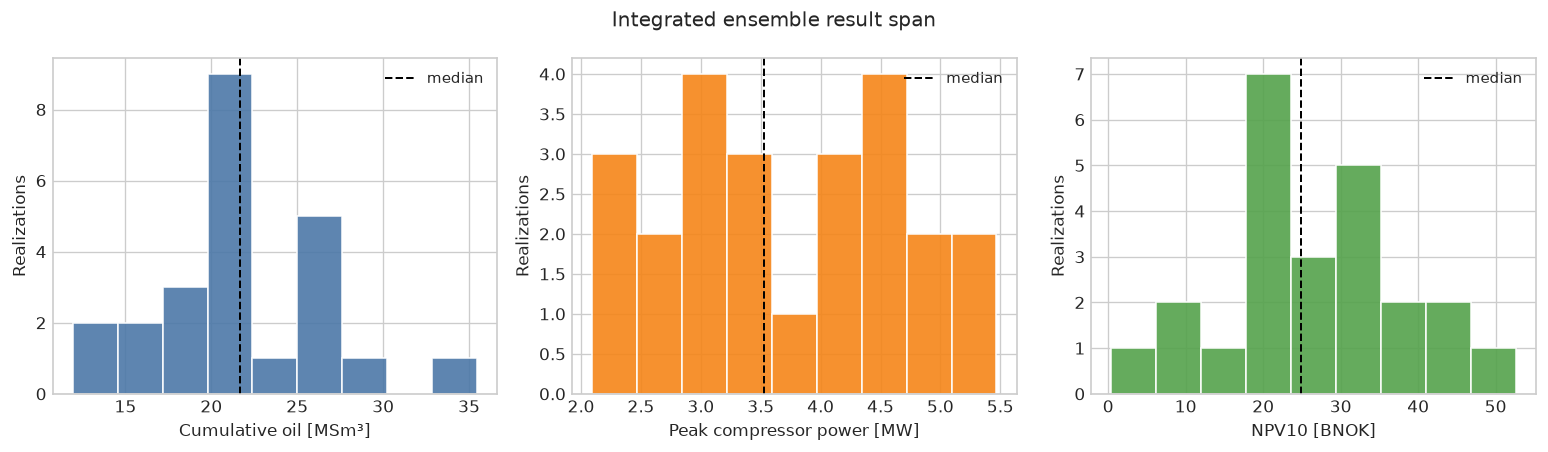

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
histogram_specs = [
    (
        "final_cumulative_oil_msm3",
        "Cumulative oil [MSm³]",
        "#4C78A8",
    ),
    (
        "peak_compressor_power_mw",
        "Peak compressor power [MW]",
        "#F58518",
    ),
    (
        "npv10_bn_nok",
        "NPV10 [BNOK]",
        "#54A24B",
    ),
]
for axis, (column_name, x_label, color) in zip(
    axes,
    histogram_specs,
):
    axis.hist(
        metrics[column_name],
        bins=9,
        color=color,
        edgecolor="white",
        alpha=0.9,
    )
    axis.axvline(
        metrics[column_name].median(),
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="median",
    )
    axis.set_xlabel(x_label)
    axis.set_ylabel("Realizations")
    axis.legend()
figure.suptitle("Integrated ensemble result span")
figure.tight_layout()
plt.show()

## 7. Production and pressure envelopes

The shaded region is Q10–Q90 across the ensemble. The solid line is the
median. These are pointwise time-series quantiles; they are not single
realizations.

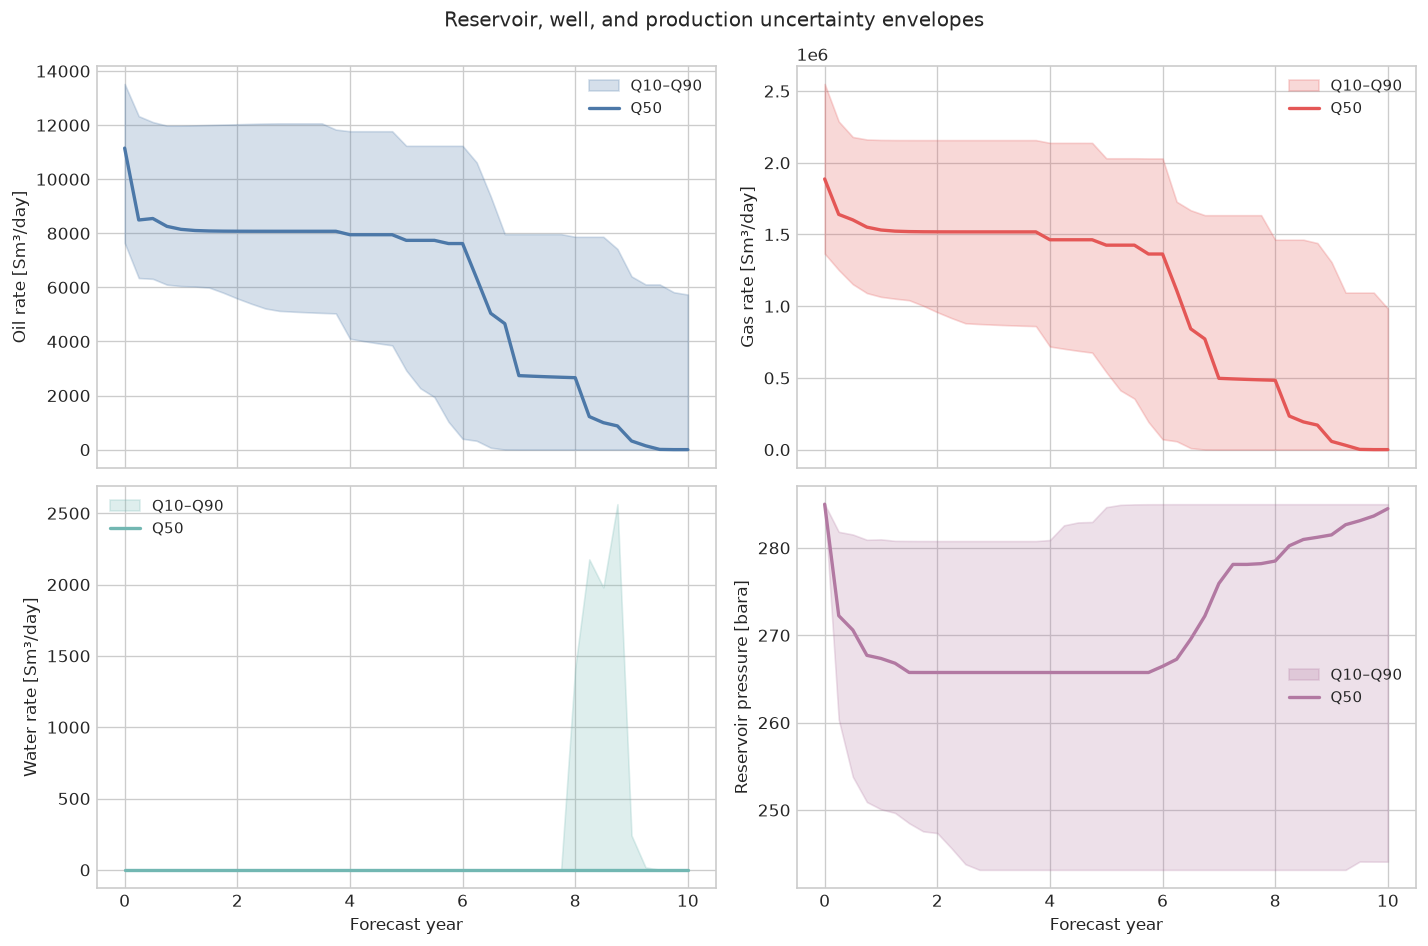

In [15]:
common_years = time_series_by_realization[0]["year"].to_numpy()


def ensemble_matrix(column_name):
    return np.vstack(
        [
            time_series_by_realization[realization][
                column_name
            ].to_numpy()
            for realization in metrics["realization"]
        ]
    )


envelope_specs = [
    (
        "oil_rate_sm3_day",
        "Oil rate [Sm³/day]",
        "#4C78A8",
    ),
    (
        "gas_rate_sm3_day",
        "Gas rate [Sm³/day]",
        "#E45756",
    ),
    (
        "water_rate_sm3_day",
        "Water rate [Sm³/day]",
        "#72B7B2",
    ),
    (
        "reservoir_pressure_bara",
        "Reservoir pressure [bara]",
        "#B279A2",
    ),
]
figure, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for axis, (column_name, y_label, color) in zip(
    axes.flat,
    envelope_specs,
):
    values = ensemble_matrix(column_name)
    lower, median, upper = np.quantile(
        values,
        [0.10, 0.50, 0.90],
        axis=0,
    )
    axis.fill_between(
        common_years,
        lower,
        upper,
        color=color,
        alpha=0.23,
        label="Q10–Q90",
    )
    axis.plot(
        common_years,
        median,
        color=color,
        linewidth=2.0,
        label="Q50",
    )
    axis.set_ylabel(y_label)
    axis.legend(loc="best")
for axis in axes[-1, :]:
    axis.set_xlabel("Forecast year")
figure.suptitle(
    "Reservoir, well, and production uncertainty envelopes"
)
figure.tight_layout()
plt.show()

## 8. Spatial waterflood response

Each reduced-order reservoir contains 40 connected finite-volume cells
along the dominant injector-to-producer flow path. The plot shows final
water saturation for representative value cases.

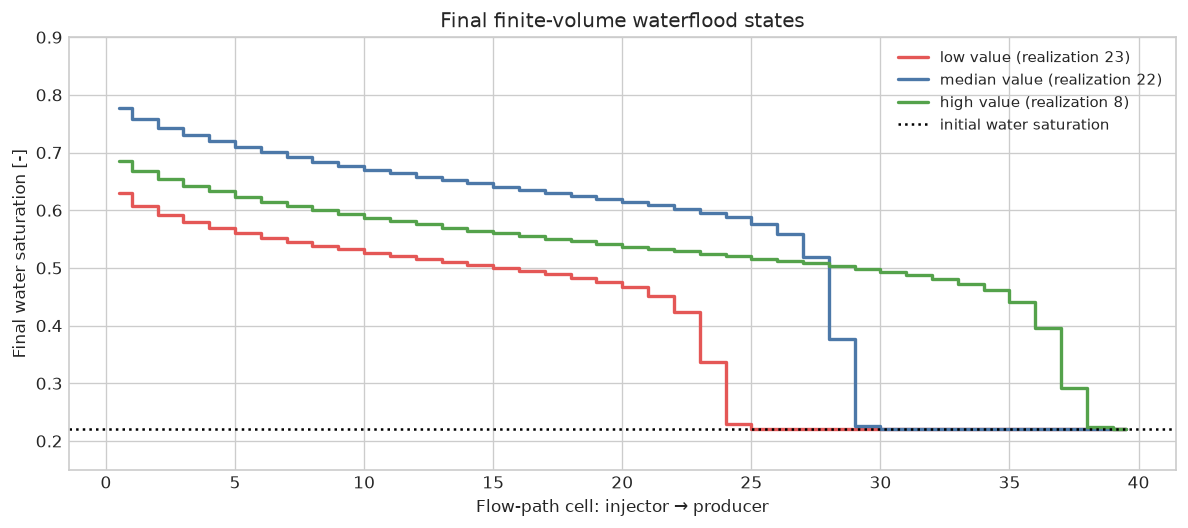

In [16]:
ordered_by_value = metrics.sort_values("npv10_bn_nok")
representative_realizations = {
    "low value": int(
        ordered_by_value.iloc[
            round(0.10 * (len(ordered_by_value) - 1))
        ]["realization"]
    ),
    "median value": int(
        ordered_by_value.iloc[
            round(0.50 * (len(ordered_by_value) - 1))
        ]["realization"]
    ),
    "high value": int(
        ordered_by_value.iloc[
            round(0.90 * (len(ordered_by_value) - 1))
        ]["realization"]
    ),
}
cell_centres = (
    np.arange(len(next(iter(saturation_by_realization.values()))))
    + 0.5
)
figure, axis = plt.subplots(figsize=(10, 4.5))
colors = ["#E45756", "#4C78A8", "#54A24B"]
for (case_label, realization), color in zip(
    representative_realizations.items(),
    colors,
):
    axis.step(
        cell_centres,
        saturation_by_realization[realization],
        where="mid",
        linewidth=2.0,
        color=color,
        label=f"{case_label} (realization {realization})",
    )
axis.axhline(
    0.22,
    color="black",
    linestyle=":",
    label="initial water saturation",
)
axis.set_xlabel("Flow-path cell: injector → producer")
axis.set_ylabel("Final water saturation [-]")
axis.set_ylim(0.15, 0.90)
axis.set_title("Final finite-volume waterflood states")
axis.legend()
figure.tight_layout()
plt.show()

## 9. NeqSim process-load span

Every realization runs three exact NeqSim SRK-CPA process cases:
peak oil, peak gas, and peak water. The flowsheet contains an inlet
choke, three-phase separator, export compressor to 110 bara, and
aftercooler to 35°C.

In [17]:
process_summary = (
    process_snapshots.groupby("snapshot")
    .agg(
        realizations=("realization", "nunique"),
        feed_q50_kg_s=("feed_mass_kg_s", "median"),
        gas_q50_kg_s=("gas_mass_kg_s", "median"),
        oil_q50_kg_s=("oil_mass_kg_s", "median"),
        water_q50_kg_s=("water_mass_kg_s", "median"),
        compressor_q90_mw=(
            "compressor_power_mw",
            lambda values: values.quantile(0.90),
        ),
        cooling_q90_mw=(
            "aftercooler_duty_mw",
            lambda values: -values.quantile(0.10),
        ),
        max_mass_residual_kg_s=(
            "mass_residual_kg_s",
            lambda values: values.abs().max(),
        ),
    )
    .reset_index()
)
display(process_summary.round(5))

,snapshot,realizations,feed_q50_kg_s,gas_q50_kg_s,oil_q50_kg_s,water_q50_kg_s,compressor_q90_mw,cooling_q90_mw,max_mass_residual_kg_s
0,peak_gas,24,124.19583,13.55085,111.00403,0.0,4.93024,6.06312,0.0
1,peak_oil,24,124.19583,13.55085,111.00403,0.0,4.93024,6.06312,0.0
2,peak_water,24,94.54681,10.72730,83.60637,0.0,4.77677,5.87429,0.0


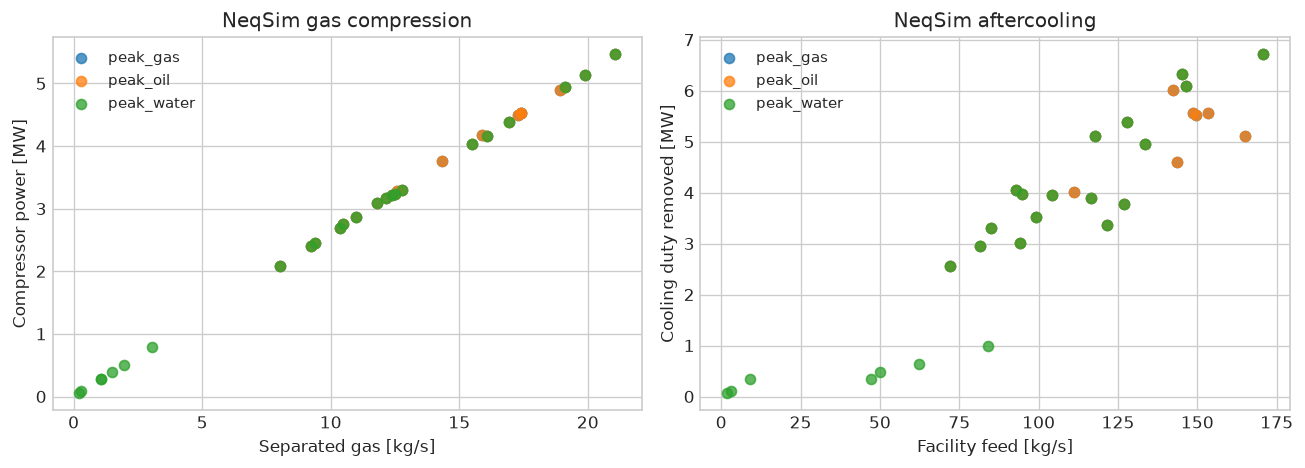

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))
for snapshot_name, group in process_snapshots.groupby("snapshot"):
    axes[0].scatter(
        group["gas_mass_kg_s"],
        group["compressor_power_mw"],
        alpha=0.75,
        label=snapshot_name,
    )
    axes[1].scatter(
        group["feed_mass_kg_s"],
        -group["aftercooler_duty_mw"],
        alpha=0.75,
        label=snapshot_name,
    )
axes[0].set_xlabel("Separated gas [kg/s]")
axes[0].set_ylabel("Compressor power [MW]")
axes[0].set_title("NeqSim gas compression")
axes[1].set_xlabel("Facility feed [kg/s]")
axes[1].set_ylabel("Cooling duty removed [MW]")
axes[1].set_title("NeqSim aftercooling")
for axis in axes:
    axis.legend()
figure.tight_layout()
plt.show()

## 10. Facility-capacity risk

Capacity limits below are screening assumptions. A realization exceeds a
limit if its unconstrained peak is above that limit. This produces a
direct probability-of-exceedance estimate conditional on the sampled
prior and the development concept.

In [19]:
capacity_limits = {
    "Oil handling": (
        "peak_oil_rate_sm3_day",
        14000.0,
        "Sm³/day",
    ),
    "Gas handling": (
        "peak_gas_rate_msm3_day",
        2.30,
        "MSm³/day",
    ),
    "Water handling": (
        "peak_water_rate_sm3_day",
        6000.0,
        "Sm³/day",
    ),
    "Compression": (
        "peak_compressor_power_mw",
        12.0,
        "MW",
    ),
}
capacity_rows = []
for capacity_name, (
    column_name,
    limit,
    unit,
) in capacity_limits.items():
    exceedance = metrics[column_name] > limit
    capacity_rows.append(
        {
            "capacity": capacity_name,
            "limit": limit,
            "unit": unit,
            "exceedance_probability": exceedance.mean(),
            "realizations_exceeding": int(exceedance.sum()),
        }
    )
capacity_risk = pd.DataFrame(capacity_rows)
display(capacity_risk)

,capacity,limit,unit,exceedance_probability,realizations_exceeding
0,Oil handling,14000.0,Sm³/day,0.083333,2
1,Gas handling,2.3,MSm³/day,0.291667,7
2,Water handling,6000.0,Sm³/day,0.000000,0
3,Compression,12.0,MW,0.000000,0


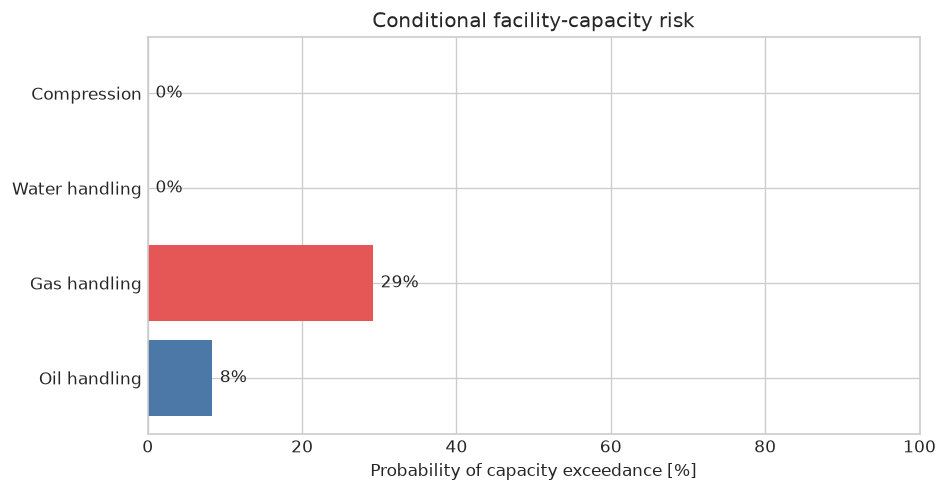

In [20]:
figure, axis = plt.subplots(figsize=(8, 4.2))
axis.barh(
    capacity_risk["capacity"],
    100.0 * capacity_risk["exceedance_probability"],
    color=["#4C78A8", "#E45756", "#72B7B2", "#F58518"],
)
axis.set_xlabel("Probability of capacity exceedance [%]")
axis.set_xlim(0.0, 100.0)
axis.set_title("Conditional facility-capacity risk")
for row_index, probability in enumerate(
    capacity_risk["exceedance_probability"]
):
    axis.text(
        100.0 * probability + 1.0,
        row_index,
        f"{100.0 * probability:.0f}%",
        va="center",
    )
figure.tight_layout()
plt.show()

## 11. Dominant uncertainty drivers

Spearman rank correlation is used as a screening sensitivity measure.
It detects monotonic relationships but does not prove causality and can
understate interactions or non-monotonic effects.

In [21]:
parameter_columns = priors["parameter"].tolist()
response_columns = {
    "Cumulative oil": "final_cumulative_oil_msm3",
    "Peak gas": "peak_gas_rate_msm3_day",
    "Peak water": "peak_water_rate_sm3_day",
    "Compression": "peak_compressor_power_mw",
    "NPV10": "npv10_bn_nok",
}
sensitivity_rows = []
for response_label, response_column in response_columns.items():
    for parameter_name in parameter_columns:
        rank_correlation, p_value = spearmanr(
            metrics[parameter_name],
            metrics[response_column],
        )
        sensitivity_rows.append(
            {
                "response": response_label,
                "parameter": parameter_name,
                "spearman_rho": rank_correlation,
                "p_value": p_value,
            }
        )
sensitivities = pd.DataFrame(sensitivity_rows)
top_sensitivities = (
    sensitivities.assign(
        absolute_rho=lambda table: table[
            "spearman_rho"
        ].abs()
    )
    .sort_values(
        ["response", "absolute_rho"],
        ascending=[True, False],
    )
    .groupby("response")
    .head(5)
)
display(
    top_sensitivities[
        [
            "response",
            "parameter",
            "spearman_rho",
            "p_value",
        ]
    ].round(3)
)

,response,parameter,spearman_rho,p_value
43,Compression,PERMEABILITY_MD,0.670,0.000
51,Compression,INITIAL_GOR_SM3_SM3,0.536,0.007
44,Compression,WELL_PI_MULT,0.339,0.105
46,Compression,COREY_WATER_EXP,-0.318,0.130
48,Compression,AREAL_SWEEP_EFF,-0.291,0.167
2,Cumulative oil,WELL_PI_MULT,0.489,0.015
0,Cumulative oil,OOIP_MSM3,0.397,0.054
1,Cumulative oil,PERMEABILITY_MD,0.330,0.116
7,Cumulative oil,VOIDAGE_REPLACEMENT,0.275,0.194
6,Cumulative oil,AREAL_SWEEP_EFF,0.256,0.228


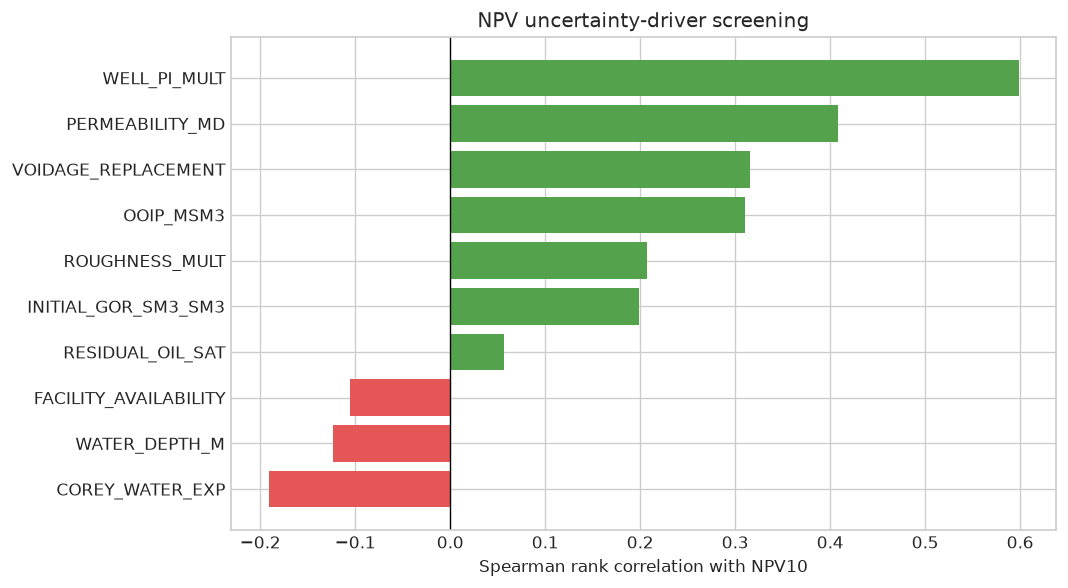

In [22]:
npv_sensitivity = (
    sensitivities.loc[sensitivities["response"] == "NPV10"]
    .sort_values(
        "spearman_rho",
        key=lambda values: values.abs(),
    )
    .tail(10)
    .sort_values("spearman_rho")
)
sensitivity_colors = np.where(
    npv_sensitivity["spearman_rho"] >= 0.0,
    "#54A24B",
    "#E45756",
)
figure, axis = plt.subplots(figsize=(9, 5))
axis.barh(
    npv_sensitivity["parameter"],
    npv_sensitivity["spearman_rho"],
    color=sensitivity_colors,
)
axis.axvline(0.0, color="black", linewidth=0.8)
axis.set_xlabel("Spearman rank correlation with NPV10")
axis.set_title("NPV uncertainty-driver screening")
figure.tight_layout()
plt.show()

## 12. Representative integrated cases

Representative cases are actual ensemble members selected by NPV rank,
not synthetic pointwise combinations of P10/P50/P90 values. This
preserves internal consistency between reservoir, well, SURF, and
process outputs.

In [23]:
representative_rows = []
for case_label, realization in representative_realizations.items():
    row = metrics.loc[
        metrics["realization"] == realization
    ].iloc[0]
    representative_rows.append(
        {
            "case": case_label,
            "realization": realization,
            "OOIP [MSm³]": row["OOIP_MSM3"],
            "perm [mD]": row["PERMEABILITY_MD"],
            "cum oil [MSm³]": row[
                "final_cumulative_oil_msm3"
            ],
            "peak gas [MSm³/d]": row[
                "peak_gas_rate_msm3_day"
            ],
            "peak water [Sm³/d]": row[
                "peak_water_rate_sm3_day"
            ],
            "compression [MW]": row[
                "peak_compressor_power_mw"
            ],
            "NPV10 [BNOK]": row["npv10_bn_nok"],
        }
    )
representative_table = pd.DataFrame(representative_rows)
display(representative_table.round(3))

,case,realization,OOIP [MSm³],perm [mD],cum oil [MSm³],peak gas [MSm³/d],peak water [Sm³/d],compression [MW],NPV10 [BNOK]
0,low value,23,44.754,181.318,16.420,1.287,0.0,2.407,10.123
1,median value,22,39.151,249.234,20.455,2.287,0.0,4.379,25.173
2,high value,8,67.048,277.395,27.025,2.399,0.0,4.500,41.848


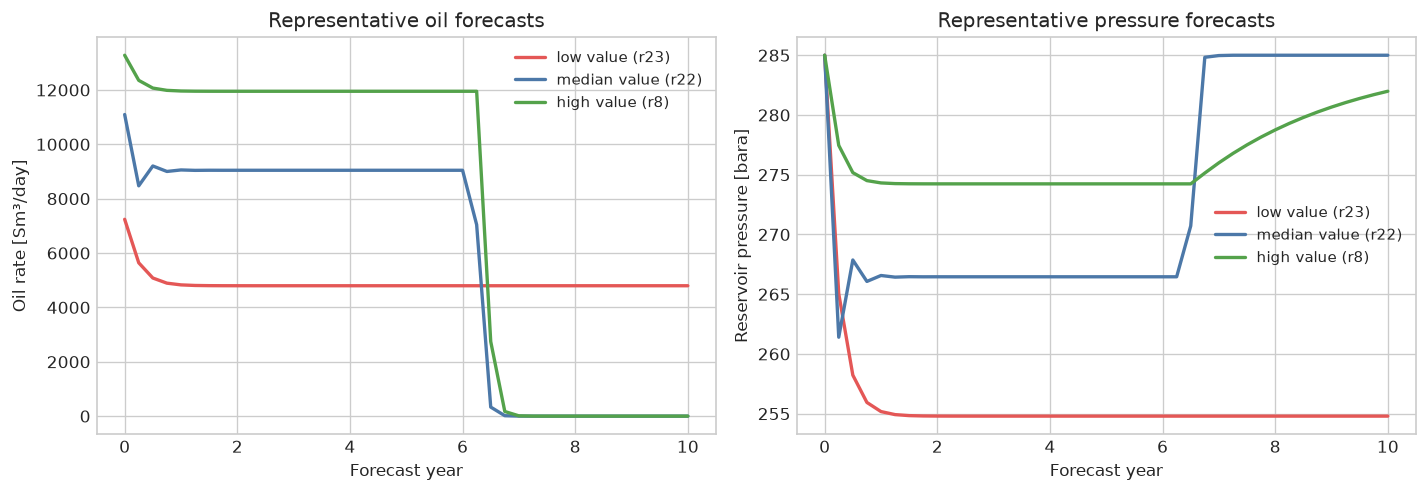

In [24]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4.2))
case_colors = {
    "low value": "#E45756",
    "median value": "#4C78A8",
    "high value": "#54A24B",
}
for case_label, realization in representative_realizations.items():
    history = time_series_by_realization[realization]
    axes[0].plot(
        history["year"],
        history["oil_rate_sm3_day"],
        linewidth=2.0,
        color=case_colors[case_label],
        label=f"{case_label} (r{realization})",
    )
    axes[1].plot(
        history["year"],
        history["reservoir_pressure_bara"],
        linewidth=2.0,
        color=case_colors[case_label],
        label=f"{case_label} (r{realization})",
    )
axes[0].set_xlabel("Forecast year")
axes[0].set_ylabel("Oil rate [Sm³/day]")
axes[0].set_title("Representative oil forecasts")
axes[1].set_xlabel("Forecast year")
axes[1].set_ylabel("Reservoir pressure [bara]")
axes[1].set_title("Representative pressure forecasts")
for axis in axes:
    axis.legend()
figure.tight_layout()
plt.show()

## 13. Validation evidence

Validation level:

1. conservation and physical-bound checks for the finite-volume and tank
   models;
2. monotonic nodal pressure losses and absolute-pressure ordering;
3. exact NeqSim three-phase calculations with process mass balance;
4. ensemble completeness and finite-response checks; and
5. expected qualitative trends across nearby uncertain cases.

This is evidence-ladder level 3 (conservation and thermodynamic
consistency) with level-4 trend checks. It is not yet benchmarked
against a history-matched OPM Flow ensemble.

In [25]:
validation_summary = (
    validation_results.groupby("check")
    .agg(
        realizations=("realization", "nunique"),
        passed=("passed", "sum"),
    )
    .reset_index()
)
validation_summary["all_passed"] = (
    validation_summary["passed"]
    == validation_summary["realizations"]
)
display(validation_summary)

response_columns_for_finiteness = [
    "final_cumulative_oil_msm3",
    "peak_gas_rate_msm3_day",
    "peak_water_rate_sm3_day",
    "peak_compressor_power_mw",
    "final_pressure_bara",
    "minimum_arrival_pressure_bara",
    "npv10_bn_nok",
]
notebook_checks = {
    "all ERT realizations succeeded": (
        len(successful_run_directories) == ENSEMBLE_SIZE
    ),
    "all realization checks passed": bool(
        validation_summary["all_passed"].all()
    ),
    "all ensemble responses finite": bool(
        np.isfinite(
            metrics[
                response_columns_for_finiteness
            ].to_numpy()
        ).all()
    ),
    "NeqSim mass residual below tolerance": bool(
        metrics[
            "maximum_process_mass_residual_kg_s"
        ].abs().max()
        < 1.0e-7
    ),
    "value quantiles ordered": bool(
        (
            value_quantiles["P90 conservative"]
            <= value_quantiles["P50 median"]
        ).all()
        and (
            value_quantiles["P50 median"]
            <= value_quantiles["P10 upside"]
        ).all()
    ),
    "load quantiles ordered": bool(
        (
            load_quantiles["Q10"]
            <= load_quantiles["Q50"]
        ).all()
        and (
            load_quantiles["Q50"]
            <= load_quantiles["Q90"]
        ).all()
    ),
}
notebook_validation = pd.DataFrame(
    {
        "check": notebook_checks.keys(),
        "passed": notebook_checks.values(),
    }
)
display(notebook_validation)
failed_notebook_checks = notebook_validation.loc[
    ~notebook_validation["passed"],
    "check",
].tolist()
if failed_notebook_checks:
    raise AssertionError(
        f"Notebook checks failed: {failed_notebook_checks}"
    )
print(
    f"All {len(notebook_checks)} notebook-level checks and "
    f"{len(validation_summary)} per-realization checks passed."
)

All 6 notebook-level checks and 10 per-realization checks passed.


,check,realizations,passed,all_passed
0,NeqSim compressor power positive,24,24,True
1,NeqSim compressor raises pressure,24,24,True
2,NeqSim cooler removes heat,24,24,True
3,NeqSim process mass closes,24,24,True
4,arrival pressure supports separator,24,24,True
5,finite time-series values,24,24,True
6,non-negative production rates,24,24,True
7,oil recovery below recoverable oil,24,24,True
8,physical saturation range,24,24,True
9,reservoir pressure bounded,24,24,True


,check,passed
0,all ERT realizations succeeded,True
1,all realization checks passed,True
2,all ensemble responses finite,True
3,NeqSim mass residual below tolerance,True
4,value quantiles ordered,True
5,load quantiles ordered,True


## Engineering interpretation

Use the calculated tables above to answer four field-development
questions:

1. **Resource span:** Is the value distribution wide enough to change
   the development decision?
2. **Deliverability:** Which permeability, PI, and hydraulic cases lose
   plateau early?
3. **Facility sizing:** Which capacity has the largest probability of
   exceedance, and is debottlenecking or staged capacity justified?
4. **Information value:** Which high-rank uncertainty drivers can be
   reduced by appraisal wells, PVT work, well tests, or SURF definition?

Capacity exceedance is not automatically a design failure. A constrained
production optimization can trade peak rate against plateau duration,
CAPEX, and NPV.

## Path to a full OPM Flow + ERT study

The ERT configuration already separates orchestration from the forward
model. For a higher-fidelity study:

1. generate one OPM deck per realization using `RUN_TEMPLATE`, `GEN_KW`,
   geomodel files, or `DESIGN_MATRIX`;
2. replace the reduced-order reservoir step with ERT's built-in
   `FORWARD_MODEL FLOW(...)`;
3. read Flow summary vectors and restart states;
4. retain the well/SURF and NeqSim handoff contract used here;
5. add production observations and run ensemble smoother or ES-MDA for
   history matching; and
6. evaluate alternative well counts and placements as separate concepts,
   not as one mixed probability distribution.

The deterministic
`neqsim_opm_flow_blackoil_coupling.ipynb` notebook provides the existing
NeqSim-generated black-oil tables, OPM deck, restart reading, and
compositional surface reconstruction needed for this replacement.

## Limitations

- The reservoir is a 40-cell dominant-flow-path model, not a
  three-dimensional corner-point geomodel.
- Scalar priors are independent and are not conditioned to seismic,
  petrophysics, well logs, pressure, or production history.
- Four producers and one facility concept are fixed.
- Well hydraulics use screening correlations rather than a mechanistic
  multiphase wellbore model.
- NeqSim fluid composition is synthetic and is not regressed to CCE, DLE,
  separator, viscosity, swelling, or compositional-gradient data.
- Process snapshots are steady-state. Control, uptime events, slugging,
  hydrate risk, relief, and dynamic operability are outside scope.
- Economics uses screening assumptions and excludes tax, schedule,
  abandonment, financing, and detailed cost uncertainty.

Replace these assumptions before asset decisions. The notebook is not a
reserves booking, facilities design, or investment-decision document.

## References and suggested exercises

Primary software references:

- [ERT documentation](https://ert.readthedocs.io/en/latest/)
- [ERT configuration guide](https://ert.readthedocs.io/en/latest/getting_started/configuration/poly_new/guide.html)
- [ERT forward models, including FLOW](https://ert.readthedocs.io/en/latest/reference/configuration/forward_model.html)
- [ERT ensemble-method theory](https://ert.readthedocs.io/en/latest/theory/ensemble_based_methods.html)
- [OPM Flow](https://opm-project.org/?page_id=19)
- [NeqSim documentation](https://equinor.github.io/neqsim/)

Suggested exercises:

1. Increase the ensemble to 100 members and test convergence of
   quantiles and rank sensitivities.
2. Add correlated porosity, net-to-gross, and permeability fields.
3. Introduce a design matrix for three-, four-, and five-producer
   concepts.
4. Add synthetic observations and compare prior and ES-MDA posterior
   spans.
5. Replace the reduced-order reservoir model with OPM Flow while
   preserving the same result schema.
6. Add bidirectional facility back-pressure iteration and constrained
   production optimization.

## Saved-notebook validation record

The delivered revision is executed top to bottom with stored outputs.
Static notebook checks, Python syntax, ERT lint, equation-source checks,
output completeness, and visual inspection are recorded outside the
engineering calculation cells. Re-run the full notebook after changing
any model or visual.